In [2]:
import pandas as pd
import numpy as np
import re
import string
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from sklearn.model_selection import train_test_split
from nltk.corpus import stopwords
import nltk
import pickle

2025-11-10 04:28:55.101034: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762748935.425224      40 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762748935.515492      40 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
df = pd.read_csv("/kaggle/input/human-vs-ai-generated-essays/balanced_ai_human_prompts.csv")
print("Jumlah data:", len(df))
display(df.sample(10))

Jumlah data: 2750


,text,generated
630,They should change to election by popular vote...,0
1291,"Cars, they make life so much easier, or, do th...",0
2583,Compile a list of key insights about nanotechn...,1
1790,Create a structured outline for global healthc...,1
2092,Write a comprehensive essay explaining history...,1
599,Citizens of the U.S. have been voting for thei...,0
1117,"I argue in changing the electoral college , po...",0
1892,Produce a balanced review of renewable energy ...,1
1351,Boom the sound of ginormous truck slamming int...,0
1743,Develop a persuasive argument about renewable ...,1


In [5]:
print("\nDistribusi Label:")
print(df['generated'].value_counts())


Distribusi Label:
generated
1    1375
0    1375
Name: count, dtype: int64


In [6]:
stop_words = set(stopwords.words("english"))
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = " ".join([w for w in text.split() if w not in stop_words])
    return text

df["clean_text"] = df["text"].apply(clean_text)

In [7]:
X = df["clean_text"].values
y = df["generated"].values

tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(X)

sequences = tokenizer.texts_to_sequences(X)
padded = pad_sequences(sequences, maxlen=200, padding='post', truncating='post')

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    padded, y, test_size=0.2, random_state=42, stratify=y
)

In [9]:
model = Sequential([
    Embedding(input_dim=10000, output_dim=100, input_length=200),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2025-11-10 04:29:14.736635: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [10]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [11]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.8731 - loss: 0.4442 - val_accuracy: 0.9977 - val_loss: 0.0154
Epoch 2/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9937 - loss: 0.0190 - val_accuracy: 0.9977 - val_loss: 0.0167
Epoch 3/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9970 - loss: 0.0076 - val_accuracy: 0.9977 - val_loss: 0.0160
Epoch 4/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 1.0000 - loss: 0.0045 - val_accuracy: 0.9977 - val_loss: 0.0210
Epoch 5/5
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.9996 - loss: 0.0013 - val_accuracy: 0.9977 - val_loss: 0.0208


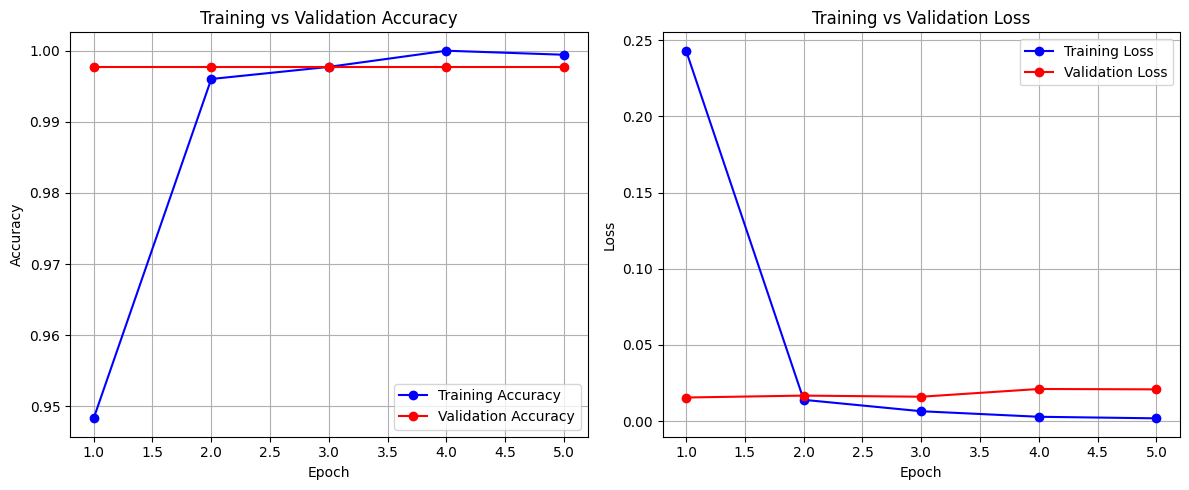

In [12]:
import matplotlib.pyplot as plt

# Ambil nilai dari history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# Plot Akurasi
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b-o', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r-o', label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b-o', label='Training Loss')
plt.plot(epochs, val_loss, 'r-o', label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [13]:
loss, acc = model.evaluate(X_test, y_test)
print(f"\nAkurasi Model CNN: {acc*100:.2f}%")

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9986 - loss: 0.0148  

Akurasi Model CNN: 99.82%


In [14]:
def predict_ai_cnn(text):
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    pad = pad_sequences(seq, maxlen=200, padding='post', truncating='post')
    prob = model.predict(pad)[0][0]
    return round(prob * 100, 2)


user_text = input("Masukkan teks yang ingin diuji: ")

print(f"\nTeks: {user_text}")
print(f"Kemungkinan teks ini dibuat oleh AI: {predict_ai_cnn(user_text)}%")

Masukkan teks yang ingin diuji:  This application is designed to automatically analyze text using a Convolutional Neural Network (CNN)-based model. Users can simply input text into the provided field, and the system will process it to display the analysis results dynamically at the bottom of the interface. The app features a modern cyberpunk-inspired design with dark tones and futuristic elements to enhance user experience and visual appeal. The top section remains static to maintain focus, while the analysis results can be scrolled separately for easier readability, even when the output is lengthy.



Teks: This application is designed to automatically analyze text using a Convolutional Neural Network (CNN)-based model. Users can simply input text into the provided field, and the system will process it to display the analysis results dynamically at the bottom of the interface. The app features a modern cyberpunk-inspired design with dark tones and futuristic elements to enhance user experience and visual appeal. The top section remains static to maintain focus, while the analysis results can be scrolled separately for easier readability, even when the output is lengthy.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
Kemungkinan teks ini dibuat oleh AI: 2.1%


In [15]:
model.save("cnn_text_classifier.h5")

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("✅ Model dan Tokenizer berhasil disimpan ke file .h5 dan .pkl")

✅ Model dan Tokenizer berhasil disimpan ke file .h5 dan .pkl
